First 5 Rows:
   Month  Sales
0      1    120
1      2    125
2      3    130
3      4    128
4      5    135

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   50 non-null     int64
 1   Sales   50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None

Missing Values:
Month    0
Sales    0
dtype: int64

Model Evaluation
MAE : 0.34
MSE : 0.15
RMSE: 0.39
R² Score: 1.0

Future Sales Forecast:
   Month  Predicted_Sales
0     51           364.44
1     52           369.41
2     53           374.37
3     54           379.34
4     55           384.31
5     56           389.27
6     57           394.24
7     58           399.21
8     59           404.17
9     60           409.14


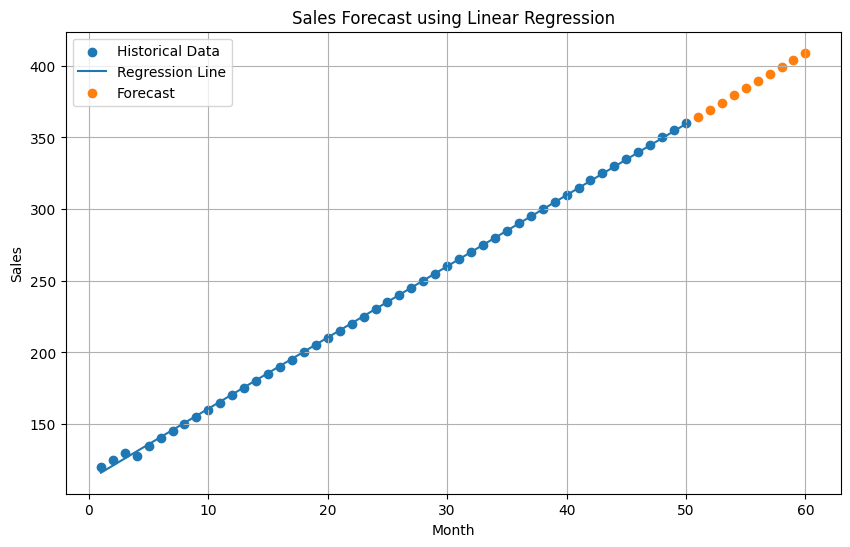

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('monthly_sales.csv')

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()

X = df[['Month']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,2))

future_months = pd.DataFrame({
    'Month':[51,52,53,54,55,56,57,58,59,60]
})

future_predictions = model.predict(future_months)

forecast_df = pd.DataFrame({
    'Month': future_months['Month'],
    'Predicted_Sales': np.round(future_predictions,2)
})

print("\nFuture Sales Forecast:")
print(forecast_df)

plt.figure(figsize=(10,6))

plt.scatter(df['Month'], df['Sales'], label='Historical Data')

plt.plot(
    df['Month'],
    model.predict(df[['Month']]),
    label='Regression Line'
)

plt.scatter(
    future_months['Month'],
    future_predictions,
    label='Forecast'
)

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales Forecast using Linear Regression')
plt.legend()
plt.grid(True)

plt.show()